导入依赖

In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from models.MobileNetV2 import MobileNetV2
from matplotlib import pyplot as plt
from models.MobileNetV2_exp_invertedBlock import MobileNetV2 as MobileNetV2_exp_IB

设置随机种子

In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 如果使用多GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 100
# 在训练代码开头调用
set_seed(seed) # 42, 2025, 1024, 512, 100

导入数据集

In [3]:
def preprocessing(tensor):
    if tensor.mean() > 0.5:
        tensor = 1 - tensor
    return tensor

In [4]:
def tensor_transform(x):
    if x.shape[1] == 1:
        return x.repeat_interleave(3, dim= 1)
    elif x.shape[1] == 4:
        return x[:, :3, :, :]
    elif x.shape[1] == 3:
        return x
    else:
        raise ValueError('Invalid input shape')

tensor_rgb_transform = transforms.Lambda(tensor_transform)

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(preprocessing),
    transforms.Normalize((0.1307, ), (0.3081, )),
    transforms.Grayscale(1)
])

In [6]:
mnist_db = datasets.MNIST(root= 'dataFolder/', train= True, transform= transform, download= True)
mnist_loader = DataLoader(mnist_db, batch_size= 128, shuffle= True)

In [7]:
our_db = datasets.ImageFolder(root= 'dataFolder/num', transform= transform)
our_loader = DataLoader(our_db, batch_size= 100, shuffle= True)
len(our_db)

36696

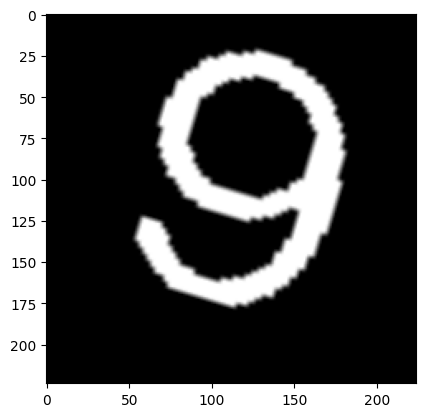

In [8]:
x, y = next(iter(our_loader))
plt.imshow(x[0][0], cmap='gray')
plt.show()

模型训练

In [9]:
def train_model(model, train_loader, in_ch):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
    model.train()

    losses = []
    for epoch in range(10):  # 训练10个周期
        correct = 0
        total = 0
        for idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            if in_ch == 3: x = tensor_rgb_transform(x)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += x.shape[0]
            correct += (torch.argmax(out, dim= -1) == y).sum().item()
            losses.append(loss.item())
            if idx % 1000 == 0:
                print('Epoch: {}, Loss: {}'.format(epoch, loss.item()))
                print('Accuracy: {:.2f}%'.format(correct * 100 / total))

    return model.state_dict(), losses

In [10]:
model_1C_IB = MobileNetV2_exp_IB(n_classes= 10, in_ch= 1)
state_dict, losses = train_model(model_1C_IB, mnist_loader, in_ch= 1)
torch.save(state_dict, f'save_models/mobV2/MobileNetV2_expIB_1C_MD_{seed}.pth')
print('MobileNetV2_exp_IB_1C saved!')

model_3C_IB = MobileNetV2_exp_IB(n_classes= 10, in_ch= 3)
state_dict, losses = train_model(model_3C_IB, mnist_loader, in_ch= 3)
torch.save(state_dict, f'save_models/mobV2/MobileNetV2_expIB_3C_MD_{seed}.pth')
print('MobileNetV2_exp_IB_3C saved!')

# model_1C = MobileNetV2(n_classes= 10, in_ch= 1)
# state_dict, losses = train_model(model_1C, mnist_loader, in_ch= 1)
# torch.save(state_dict, f'save_models/mobV2/MobileNetV2_1C_MD_{seed}.pth')
# print('MobileNetV2_1C saved!')

# model_3C = MobileNetV2(n_classes= 10, in_ch= 3)
# state_dict, losses = train_model(model_3C, mnist_loader, in_ch= 3)
# torch.save(state_dict, f'save_models/mobV2/MobileNetV2_3C_MD_{seed}.pth')
# print('MobileNetV2_3C saved!')

# model_1D = MobileNetV2(n_classes= 10, in_ch= 1)
# state_dict, losses = train_model(model_1D, our_loader, in_ch= 1)
# torch.save(state_dict, f'save_models/OD/MobileNetV2_1C_OD_{seed}.pth')
# print('MobileNetV2_1C saved!')

# model_3D = MobileNetV2(n_classes= 10, in_ch= 3)
# state_dict, losses = train_model(model_3D, our_loader, in_ch= 3)
# torch.save(state_dict, f'save_models/OD/MobileNetV2_3C_OD_{seed}.pth')
# print('MobileNetV2_3C saved!')

Epoch: 0, Loss: 2.3257579803466797
Accuracy: 10.94%
Epoch: 1, Loss: 0.128010556101799
Accuracy: 93.75%
Epoch: 2, Loss: 0.07813244313001633
Accuracy: 97.66%
Epoch: 3, Loss: 0.019730253145098686
Accuracy: 100.00%
Epoch: 4, Loss: 0.05381038784980774
Accuracy: 99.22%
Epoch: 5, Loss: 0.05871153622865677
Accuracy: 98.44%
Epoch: 6, Loss: 0.01860283501446247
Accuracy: 99.22%
Epoch: 7, Loss: 0.04492560774087906
Accuracy: 96.88%
Epoch: 8, Loss: 0.024570830166339874
Accuracy: 98.44%
Epoch: 9, Loss: 0.0059098671190440655
Accuracy: 100.00%
MobileNetV2_exp_IB_1C saved!
Epoch: 0, Loss: 2.3986103534698486
Accuracy: 7.81%
Epoch: 1, Loss: 0.10049920529127121
Accuracy: 96.88%
Epoch: 2, Loss: 0.05116112902760506
Accuracy: 99.22%
Epoch: 3, Loss: 0.01729927770793438
Accuracy: 100.00%
Epoch: 4, Loss: 0.010085306130349636
Accuracy: 100.00%
Epoch: 5, Loss: 0.011716536246240139
Accuracy: 99.22%
Epoch: 6, Loss: 0.02653367817401886
Accuracy: 98.44%
Epoch: 7, Loss: 0.03814736008644104
Accuracy: 97.66%
Epoch: 8, Lo